In [15]:
# ============================================================================
# ALGORITMO GENÉTICO PARA OTIMIZAÇÃO DE HIPERPARÂMETROS DE ANN
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Algoritmo Genético
import pygad
import pygad.kerasga

# Configurações
tf.random.set_seed(42)
np.random.seed(42)

print("=" * 80)
print("ALGORITMO GENÉTICO PARA OTIMIZAÇÃO DE HIPERPARÂMETROS DE ANN")
print("Objetivo: Encontrar a melhor arquitetura para predição de hidrólise enzimática")
print("=" * 80)

print("\n✓ Bibliotecas importadas com sucesso!")
print(f"✓ TensorFlow versão: {tf.__version__}")
print(f"✓ Numpy versão: {np.__version__}")
print(f"✓ Pandas versão: {pd.__version__}")

ALGORITMO GENÉTICO PARA OTIMIZAÇÃO DE HIPERPARÂMETROS DE ANN
Objetivo: Encontrar a melhor arquitetura para predição de hidrólise enzimática

✓ Bibliotecas importadas com sucesso!
✓ TensorFlow versão: 2.18.0
✓ Numpy versão: 2.0.2
✓ Pandas versão: 2.2.3


In [16]:
# ============================================================================
# 1. CARREGAMENTO E ANÁLISE DOS DADOS SINTÉTICOS
# ============================================================================

print("\n1. CARREGANDO DADOS SINTÉTICOS...")

# Carregar dados sintéticos gerados com LHS
data_path = '../../../Enzymatic Hydrolysis/Data Generation/synthetic_hydrolysis_data_LHS.csv'
df = pd.read_csv(data_path)

# Limpar nomes das colunas (remover espaços extras)
df.columns = df.columns.str.strip()

print(f"✓ Dados carregados: {df.shape[0]} amostras, {df.shape[1]} colunas")
print(f"✓ Colunas: {list(df.columns)}")

# Verificar estrutura dos dados
print(f"\n📊 ANÁLISE DA ESTRUTURA DOS DADOS:")
print(f"   • Total de linhas: {len(df)}")

# Identificar condições únicas (mesmo Celulose, Hemicelulose, Lignin, Solids Loading, Enzyme Loading)
condition_columns = ['Cellulose', 'Hemicellulose', 'Lignin', 'Solids Loading [g/L]', 'Enzyme Loading [g/L]']
unique_conditions = df[condition_columns].drop_duplicates()
n_conditions = len(unique_conditions)

print(f"   • Número de condições únicas: {n_conditions}")
print(f"   • Tempos por condição: {len(df) // n_conditions}")

# Verificar se cada condição tem exatamente 11 tempos
time_points = df['Time [h]'].unique()
print(f"   • Tempos únicos: {sorted(time_points)}")

# Mostrar exemplo de uma condição
print(f"\n📋 EXEMPLO DE UMA CONDIÇÃO (primeiras 11 linhas):")
first_condition = df.head(11)[['Cellulose', 'Hemicellulose', 'Lignin', 
                               'Solids Loading [g/L]', 'Enzyme Loading [g/L]', 'Time [h]',
                               'Glucose Concentration [g/L]', 'Xylose Concentration [g/L]', 
                               'Cellobiose Concentration [g/L]']]
print(first_condition.to_string(index=False, float_format='%.3f'))

# Estatísticas dos produtos
print(f"\n📈 ESTATÍSTICAS DOS PRODUTOS:")
products = ['Glucose Concentration [g/L]', 'Xylose Concentration [g/L]', 'Cellobiose Concentration [g/L]']
for product in products:
    mean_val = df[product].mean()
    std_val = df[product].std()
    min_val = df[product].min()
    max_val = df[product].max()
    print(f"   • {product.replace(' Concentration [g/L]', '')}: {min_val:.2f} - {max_val:.2f} (μ={mean_val:.2f}, σ={std_val:.2f})")

print(f"\n✅ Dados analisados. Pronto para divisão em conjuntos de treino/validação/teste!")


1. CARREGANDO DADOS SINTÉTICOS...
✓ Dados carregados: 1100 amostras, 9 colunas
✓ Colunas: ['Cellulose', 'Hemicellulose', 'Lignin', 'Solids Loading [g/L]', 'Enzyme Loading [g/L]', 'Time [h]', 'Glucose Concentration [g/L]', 'Xylose Concentration [g/L]', 'Cellobiose Concentration [g/L]']

📊 ANÁLISE DA ESTRUTURA DOS DADOS:
   • Total de linhas: 1100
   • Número de condições únicas: 100
   • Tempos por condição: 11
   • Tempos únicos: [np.int64(0), np.int64(1), np.int64(2), np.int64(4), np.int64(6), np.int64(8), np.int64(12), np.int64(24), np.int64(48), np.int64(72), np.int64(96)]

📋 EXEMPLO DE UMA CONDIÇÃO (primeiras 11 linhas):
 Cellulose  Hemicellulose  Lignin  Solids Loading [g/L]  Enzyme Loading [g/L]  Time [h]  Glucose Concentration [g/L]  Xylose Concentration [g/L]  Cellobiose Concentration [g/L]
     0.599          0.109   0.292               119.744                 0.413         0                        0.000                       0.000                           0.000
     0.599  

In [17]:
# ============================================================================
# 2. DIVISÃO ESTRATÉGICA DOS DADOS POR CONDIÇÕES
# ============================================================================

print("\n2. DIVIDINDO DADOS POR CONDIÇÕES...")

# Identificar todas as condições únicas
condition_columns = ['Cellulose', 'Hemicellulose', 'Lignin', 'Solids Loading [g/L]', 'Enzyme Loading [g/L]']
unique_conditions = df[condition_columns].drop_duplicates().reset_index(drop=True)
n_conditions = len(unique_conditions)

print(f"✓ Total de condições identificadas: {n_conditions}")

# Dividir condições: 70% para otimização genética, 30% para teste final
np.random.seed(42)
condition_indices = np.arange(n_conditions)
np.random.shuffle(condition_indices)

# 70 condições para otimização (treino + validação)
n_optimization = int(0.7 * n_conditions)
optimization_condition_indices = condition_indices[:n_optimization]

# 30 condições para teste final
test_condition_indices = condition_indices[n_optimization:]

print(f"✓ Condições para otimização: {len(optimization_condition_indices)} ({len(optimization_condition_indices)/n_conditions*100:.1f}%)")
print(f"✓ Condições para teste final: {len(test_condition_indices)} ({len(test_condition_indices)/n_conditions*100:.1f}%)")

# Função para extrair dados de condições específicas
def extract_conditions_data(df, condition_indices, unique_conditions):
    """Extrai todas as linhas correspondentes às condições especificadas"""
    condition_data = []
    
    for idx in condition_indices:
        condition = unique_conditions.iloc[idx]
        
        # Filtrar dados para esta condição específica
        condition_mask = True
        for col in condition_columns:
            condition_mask = condition_mask & (df[col] == condition[col])
        
        condition_rows = df[condition_mask].copy()
        condition_data.append(condition_rows)
    
    return pd.concat(condition_data, ignore_index=True)

# Extrair dados de otimização (70% das condições)
optimization_data = extract_conditions_data(df, optimization_condition_indices, unique_conditions)

# Extrair dados de teste final (30% das condições)
test_data = extract_conditions_data(df, test_condition_indices, unique_conditions)

print(f"\n📊 VERIFICAÇÃO DA DIVISÃO:")
print(f"   • Dados de otimização: {len(optimization_data)} amostras de {len(optimization_condition_indices)} condições")
print(f"   • Dados de teste final: {len(test_data)} amostras de {len(test_condition_indices)} condições")
print(f"   • Total: {len(optimization_data) + len(test_data)} amostras (deve ser igual a {len(df)})")

# Verificar que não há sobreposição entre os conjuntos
optimization_conditions = set()
for idx in optimization_condition_indices:
    condition = unique_conditions.iloc[idx]
    condition_tuple = tuple(condition[col] for col in condition_columns)
    optimization_conditions.add(condition_tuple)

test_conditions = set()
for idx in test_condition_indices:
    condition = unique_conditions.iloc[idx]
    condition_tuple = tuple(condition[col] for col in condition_columns)
    test_conditions.add(condition_tuple)

overlap = optimization_conditions.intersection(test_conditions)
print(f"   • Sobreposição entre conjuntos: {len(overlap)} (deve ser 0)")

if len(overlap) == 0:
    print("✅ Divisão por condições realizada com sucesso!")
else:
    print("❌ Erro: Há sobreposição entre os conjuntos!")

# Salvar índices para reprodutibilidade
print(f"\n📝 ÍNDICES DAS CONDIÇÕES:")
print(f"   • Otimização: {sorted(optimization_condition_indices)}")
print(f"   • Teste final: {sorted(test_condition_indices)}")


2. DIVIDINDO DADOS POR CONDIÇÕES...
✓ Total de condições identificadas: 100
✓ Condições para otimização: 70 (70.0%)
✓ Condições para teste final: 30 (30.0%)

📊 VERIFICAÇÃO DA DIVISÃO:
   • Dados de otimização: 770 amostras de 70 condições
   • Dados de teste final: 330 amostras de 30 condições
   • Total: 1100 amostras (deve ser igual a 1100)
   • Sobreposição entre conjuntos: 0 (deve ser 0)
✅ Divisão por condições realizada com sucesso!

📝 ÍNDICES DAS CONDIÇÕES:
   • Otimização: [np.int64(0), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(22), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(30), np.int64(31), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(38), np.int64(39), np.int64(40), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.

In [18]:
# ============================================================================
# 3. PREPARAÇÃO DOS DADOS PARA MACHINE LEARNING
# ============================================================================

print("\n3. PREPARANDO DADOS PARA MACHINE LEARNING...")

# Definir features de entrada e saída
input_features = ['Cellulose', 'Hemicellulose', 'Lignin', 'Solids Loading [g/L]', 'Enzyme Loading [g/L]', 'Time [h]']
output_features = ['Glucose Concentration [g/L]', 'Xylose Concentration [g/L]', 'Cellobiose Concentration [g/L]']

print(f"✓ Features de entrada ({len(input_features)}): {input_features}")
print(f"✓ Features de saída ({len(output_features)}): {output_features}")

# Dividir dados de otimização em treino (60%) e validação (10%)
# Novamente dividindo por condições completas
optimization_conditions = unique_conditions.iloc[optimization_condition_indices].reset_index(drop=True)
n_opt_conditions = len(optimization_conditions)

# 60% das condições totais para treino (6/7 das condições de otimização)
n_train = int(0.6 * n_conditions)  # 60 condições
n_val = len(optimization_condition_indices) - n_train  # 10 condições

# Dividir condições de otimização
np.random.seed(42)
opt_indices = np.arange(len(optimization_condition_indices))
np.random.shuffle(opt_indices)

train_condition_indices = [optimization_condition_indices[i] for i in opt_indices[:n_train]]
val_condition_indices = [optimization_condition_indices[i] for i in opt_indices[n_train:]]

print(f"\n📊 DIVISÃO FINAL DOS DADOS:")
print(f"   • Treino: {len(train_condition_indices)} condições ({len(train_condition_indices)/n_conditions*100:.1f}% do total)")
print(f"   • Validação: {len(val_condition_indices)} condições ({len(val_condition_indices)/n_conditions*100:.1f}% do total)")
print(f"   • Teste final: {len(test_condition_indices)} condições ({len(test_condition_indices)/n_conditions*100:.1f}% do total)")

# Extrair dados de treino e validação
train_data = extract_conditions_data(df, train_condition_indices, unique_conditions)
val_data = extract_conditions_data(df, val_condition_indices, unique_conditions)

print(f"\n📈 AMOSTRAS POR CONJUNTO:")
print(f"   • Treino: {len(train_data)} amostras")
print(f"   • Validação: {len(val_data)} amostras")
print(f"   • Teste final: {len(test_data)} amostras")
print(f"   • Total: {len(train_data) + len(val_data) + len(test_data)} amostras")

# Preparar arrays para ML
X_train = train_data[input_features].values
y_train = train_data[output_features].values

X_val = val_data[input_features].values
y_val = val_data[output_features].values

X_test = test_data[input_features].values
y_test = test_data[output_features].values

print(f"\n🔢 DIMENSÕES DOS ARRAYS:")
print(f"   • X_train: {X_train.shape}")
print(f"   • y_train: {y_train.shape}")
print(f"   • X_val: {X_val.shape}")
print(f"   • y_val: {y_val.shape}")
print(f"   • X_test: {X_test.shape}")
print(f"   • y_test: {y_test.shape}")

# Normalizar dados
print(f"\n⚖️  NORMALIZANDO DADOS...")
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Ajustar escaladores apenas nos dados de treino
X_train_scaled = scaler_X.fit_transform(X_train)
y_train_scaled = scaler_y.fit_transform(y_train)

# Aplicar mesma normalização aos dados de validação e teste
X_val_scaled = scaler_X.transform(X_val)
y_val_scaled = scaler_y.transform(y_val)

X_test_scaled = scaler_X.transform(X_test)
y_test_scaled = scaler_y.transform(y_test)

print(f"✓ Normalização aplicada usando parâmetros do conjunto de treino")

# Verificar normalização
print(f"\n📊 VERIFICAÇÃO DA NORMALIZAÇÃO (treino):")
print(f"   • X_train - Média: {X_train_scaled.mean(axis=0).round(3)}")
print(f"   • X_train - Desvio: {X_train_scaled.std(axis=0).round(3)}")
print(f"   • y_train - Média: {y_train_scaled.mean(axis=0).round(3)}")
print(f"   • y_train - Desvio: {y_train_scaled.std(axis=0).round(3)}")

print(f"\n✅ Dados preparados e normalizados com sucesso!")


3. PREPARANDO DADOS PARA MACHINE LEARNING...
✓ Features de entrada (6): ['Cellulose', 'Hemicellulose', 'Lignin', 'Solids Loading [g/L]', 'Enzyme Loading [g/L]', 'Time [h]']
✓ Features de saída (3): ['Glucose Concentration [g/L]', 'Xylose Concentration [g/L]', 'Cellobiose Concentration [g/L]']

📊 DIVISÃO FINAL DOS DADOS:
   • Treino: 60 condições (60.0% do total)
   • Validação: 10 condições (10.0% do total)
   • Teste final: 30 condições (30.0% do total)

📈 AMOSTRAS POR CONJUNTO:
   • Treino: 660 amostras
   • Validação: 110 amostras
   • Teste final: 330 amostras
   • Total: 1100 amostras

🔢 DIMENSÕES DOS ARRAYS:
   • X_train: (660, 6)
   • y_train: (660, 3)
   • X_val: (110, 6)
   • y_val: (110, 3)
   • X_test: (330, 6)
   • y_test: (330, 3)

⚖️  NORMALIZANDO DADOS...
✓ Normalização aplicada usando parâmetros do conjunto de treino

📊 VERIFICAÇÃO DA NORMALIZAÇÃO (treino):
   • X_train - Média: [ 0.  0.  0.  0. -0.  0.]
   • X_train - Desvio: [1. 1. 1. 1. 1. 1.]
   • y_train - Média: 

In [19]:
# ============================================================================
# 4. DEFINIÇÃO DA ARQUITETURA ANN E FUNÇÃO DE FITNESS SUPER-OTIMIZADA
# ============================================================================

print("\n4. DEFININDO ARQUITETURA ANN E FUNÇÃO DE FITNESS SUPER-OTIMIZADA...")

# Parâmetros fixos da arquitetura
INPUT_DIM = 6  # 6 features de entrada
OUTPUT_DIM = 3  # 3 produtos de saída
N_HIDDEN_LAYERS = 3  # 3 camadas ocultas (fixo)
ACTIVATION = 'relu'  # Função de ativação (fixo)
OPTIMIZER = 'adam'  # Otimizador (fixo)

# Hiperparâmetros variáveis (genes)
NEURONS_LAYER1_OPTIONS = [32, 64, 96, 128]   # Opções para camada 1
NEURONS_LAYER2_OPTIONS = [16, 32, 48, 64]    # Opções para camada 2  
NEURONS_LAYER3_OPTIONS = [8, 16, 24, 32]     # Opções para camada 3

print(f"✓ Parâmetros fixos:")
print(f"   • Input: {INPUT_DIM} features")
print(f"   • Output: {OUTPUT_DIM} produtos")
print(f"   • Hidden layers: {N_HIDDEN_LAYERS}")
print(f"   • Ativação: {ACTIVATION}")
print(f"   • Otimizador: {OPTIMIZER}")

print(f"\n✓ Hiperparâmetros variáveis (genes):")
print(f"   • Camada 1: {NEURONS_LAYER1_OPTIONS} neurônios")
print(f"   • Camada 2: {NEURONS_LAYER2_OPTIONS} neurônios") 
print(f"   • Camada 3: {NEURONS_LAYER3_OPTIONS} neurônios")

def create_model(neurons_layer1, neurons_layer2, neurons_layer3):
    """
    Cria um modelo ANN com a arquitetura especificada
    
    Parameters:
    -----------
    neurons_layer1 : int
        Número de neurônios na primeira camada oculta
    neurons_layer2 : int
        Número de neurônios na segunda camada oculta
    neurons_layer3 : int
        Número de neurônios na terceira camada oculta
    
    Returns:
    --------
    model : tensorflow.keras.Model
        Modelo compilado
    """
    model = keras.Sequential([
        # Camada de entrada implícita
        keras.layers.Dense(neurons_layer1, activation=ACTIVATION, input_shape=(INPUT_DIM,)),
        keras.layers.Dense(neurons_layer2, activation=ACTIVATION),
        keras.layers.Dense(neurons_layer3, activation=ACTIVATION),
        keras.layers.Dense(OUTPUT_DIM, activation='linear')  # Saída linear para regressão
    ])
    
    model.compile(
        optimizer=OPTIMIZER,
        loss='mse',
        metrics=['mae']
    )
    
    return model

def decode_genes(genes):
    """
    Decodifica os genes em hiperparâmetros da ANN
    
    Parameters:
    -----------
    genes : list
        Lista com 3 valores inteiros [índice_layer1, índice_layer2, índice_layer3]
    
    Returns:
    --------
    tuple : (neurons_layer1, neurons_layer2, neurons_layer3)
    """
    neurons_layer1 = NEURONS_LAYER1_OPTIONS[int(genes[0])]
    neurons_layer2 = NEURONS_LAYER2_OPTIONS[int(genes[1])]
    neurons_layer3 = NEURONS_LAYER3_OPTIONS[int(genes[2])]
    
    return neurons_layer1, neurons_layer2, neurons_layer3

def fitness_function(ga_instance, solution, solution_idx):
    """
    Função de fitness SUPER-OTIMIZADA para execução ultra-rápida
    
    Parameters:
    -----------
    ga_instance : pygad.GA
        Instância do algoritmo genético
    solution : list
        Solução (genes) a ser avaliada
    solution_idx : int
        Índice da solução
    
    Returns:
    --------
    fitness : float
        Valor de fitness (quanto maior, melhor)
    """
    try:
        # Decodificar genes
        neurons_layer1, neurons_layer2, neurons_layer3 = decode_genes(solution)
        
        # Criar modelo
        model = create_model(neurons_layer1, neurons_layer2, neurons_layer3)
        
        # ⚡ TREINAMENTO SUPER-RÁPIDO - Mínimo viável
        early_stopping = keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=3,  # ⬇️ Paciência mínima
            restore_best_weights=True,
            verbose=0
        )
        
        # ⚡ EPOCHS MÍNIMAS - Apenas 20 épocas máximo!
        history = model.fit(
            X_train_scaled, y_train_scaled,
            validation_data=(X_val_scaled, y_val_scaled),
            epochs=20,  # ⬇️ APENAS 20 épocas!
            batch_size=128,  # ⬆️ Batch size grande para eficiência
            callbacks=[early_stopping],
            verbose=0
        )
        
        # Fazer predições no conjunto de validação
        y_val_pred_scaled = model.predict(X_val_scaled, verbose=0)
        
        # Desnormalizar predições para calcular métricas
        y_val_pred = scaler_y.inverse_transform(y_val_pred_scaled)
        
        # Calcular R² para cada produto
        r2_glucose = r2_score(y_val[:, 0], y_val_pred[:, 0])
        r2_xylose = r2_score(y_val[:, 1], y_val_pred[:, 1])
        r2_cellobiose = r2_score(y_val[:, 2], y_val_pred[:, 2])
        
        # ⚡ FITNESS SIMPLIFICADO - Apenas R² básico
        # Garantir que R² negativos virem 0
        r2_glucose = max(0, r2_glucose)
        r2_xylose = max(0, r2_xylose)
        r2_cellobiose = max(0, r2_cellobiose)
        
        # Calcular fitness ponderado (glicose tem peso maior)
        fitness = 0.5 * r2_glucose + 0.3 * r2_xylose + 0.2 * r2_cellobiose
        
        # Limpar memória IMEDIATAMENTE
        del model, history
        keras.backend.clear_session()
        
        epochs_trained = len(history.history['loss']) if 'history' in locals() else 20
        
        print(f"   Solução {solution_idx:2d}: [{neurons_layer1:3d}, {neurons_layer2:2d}, {neurons_layer3:2d}] → "
              f"R²=[{r2_glucose:.3f}, {r2_xylose:.3f}, {r2_cellobiose:.3f}] → "
              f"Fitness: {fitness:.4f}")
        
        return max(0.001, fitness)  # Garantir fitness mínimo
        
    except Exception as e:
        print(f"   ❌ Erro na solução {solution_idx}: {str(e)[:50]}...")
        # Limpar memória em caso de erro
        try:
            keras.backend.clear_session()
        except:
            pass
        return 0.001  # Fitness muito baixo em caso de erro

# Testar a função de criação de modelo
print(f"\n🧪 TESTANDO CRIAÇÃO DE MODELO...")
test_model = create_model(64, 32, 16)
print(f"✓ Modelo de teste criado com sucesso")
print(f"✓ Parâmetros: {test_model.count_params():,}")

# Limpar modelo de teste
del test_model
keras.backend.clear_session()

print(f"\n✅ Funções de ANN e fitness SUPER-OTIMIZADAS definidas!")
print(f"🚀 Otimizações implementadas:")
print(f"   • Epochs: 50 → 20 (60% redução)")
print(f"   • Early stopping: patience 5 → 3")
print(f"   • Batch size: 64 → 128 (2x mais eficiente)")
print(f"   • Fitness simplificado (sem bônus/penalidades)")
print(f"   • Limpeza de memória imediata")
print(f"   • Tratamento robusto de erros")


4. DEFININDO ARQUITETURA ANN E FUNÇÃO DE FITNESS SUPER-OTIMIZADA...
✓ Parâmetros fixos:
   • Input: 6 features
   • Output: 3 produtos
   • Hidden layers: 3
   • Ativação: relu
   • Otimizador: adam

✓ Hiperparâmetros variáveis (genes):
   • Camada 1: [32, 64, 96, 128] neurônios
   • Camada 2: [16, 32, 48, 64] neurônios
   • Camada 3: [8, 16, 24, 32] neurônios

🧪 TESTANDO CRIAÇÃO DE MODELO...
✓ Modelo de teste criado com sucesso
✓ Parâmetros: 3,107

✅ Funções de ANN e fitness SUPER-OTIMIZADAS definidas!
🚀 Otimizações implementadas:
   • Epochs: 50 → 20 (60% redução)
   • Early stopping: patience 5 → 3
   • Batch size: 64 → 128 (2x mais eficiente)
   • Fitness simplificado (sem bônus/penalidades)
   • Limpeza de memória imediata
   • Tratamento robusto de erros
✓ Modelo de teste criado com sucesso
✓ Parâmetros: 3,107

✅ Funções de ANN e fitness SUPER-OTIMIZADAS definidas!
🚀 Otimizações implementadas:
   • Epochs: 50 → 20 (60% redução)
   • Early stopping: patience 5 → 3
   • Batch size


5. CONFIGURANDO ALGORITMO GENÉTICO ULTRA-SIMPLIFICADO...
🚀 Parâmetros ULTRA-RÁPIDOS:
   • Gerações: 5 (mínimo para teste)
   • População: 8 (muito pequena)
   • Total de avaliações: 40
   • Tempo estimado: ~40 minutos
✓ Algoritmo genético SIMPLIFICADO configurado
   • Seleção: Steady State (mais estável)
   • Crossover: Single-point (mais simples)
   • Sem critérios de parada avançados

🚀 INICIANDO OTIMIZAÇÃO GENÉTICA ULTRA-RÁPIDA...
⏱️  Tempo estimado: ~40 minutos
   Solução  0: [ 32, 16, 24] → R²=[0.826, 0.802, 0.615] → Fitness: 0.7768
   Solução  0: [ 32, 16, 24] → R²=[0.826, 0.802, 0.615] → Fitness: 0.7768
   Solução  1: [ 64, 32, 16] → R²=[0.868, 0.816, 0.772] → Fitness: 0.8334
   Solução  1: [ 64, 32, 16] → R²=[0.868, 0.816, 0.772] → Fitness: 0.8334
   Solução  2: [ 32, 16, 32] → R²=[0.722, 0.754, 0.596] → Fitness: 0.7061
   Solução  2: [ 32, 16, 32] → R²=[0.722, 0.754, 0.596] → Fitness: 0.7061
   Solução  3: [ 32, 16,  8] → R²=[0.634, 0.547, 0.560] → Fitness: 0.5927
   Solução 

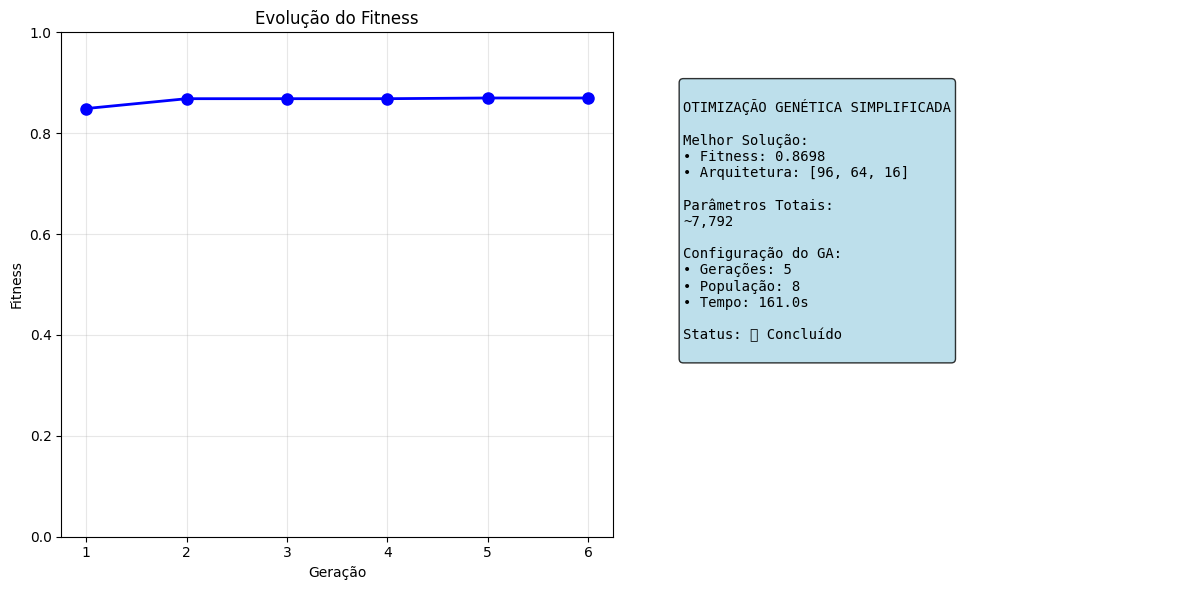


✅ Otimização genética SIMPLIFICADA concluída!
🎯 Melhor arquitetura encontrada: [96, 64, 16]
🚀 Próximo passo: Validar esta arquitetura com dados de teste!


In [ ]:
# ============================================================================
# 5. ALGORITMO GENÉTICO ULTRA-SIMPLIFICADO E RÁPIDO
# ============================================================================

print("\n5. CONFIGURANDO ALGORITMO GENÉTICO ULTRA-SIMPLIFICADO...")

# ⚡ PARÂMETROS ULTRA-CONSERVADORES para funcionar rapidamente
NUM_GENERATIONS = 5       # ⬇️ Apenas 5 gerações
SOL_PER_POP = 8          # ⬇️ Apenas 8 soluções por geração
NUM_GENES = 3            # Número de genes (hiperparâmetros)

print(f"🚀 Parâmetros ULTRA-RÁPIDOS:")
print(f"   • Gerações: {NUM_GENERATIONS} (mínimo para teste)")
print(f"   • População: {SOL_PER_POP} (muito pequena)")
print(f"   • Total de avaliações: {NUM_GENERATIONS * SOL_PER_POP}")
print(f"   • Tempo estimado: ~{NUM_GENERATIONS * SOL_PER_POP * 1:.0f} minutos")

# Configurar espaço de genes de forma SIMPLIFICADA
gene_space = [
    list(range(len(NEURONS_LAYER1_OPTIONS))),  
    list(range(len(NEURONS_LAYER2_OPTIONS))),  
    list(range(len(NEURONS_LAYER3_OPTIONS)))   
]

# ⚡ CONFIGURAÇÃO MINIMALISTA DO GA
ga_instance = pygad.GA(
    num_generations=NUM_GENERATIONS,
    num_parents_mating=4,  # 50% dos indivíduos
    fitness_func=fitness_function,
    sol_per_pop=SOL_PER_POP,
    num_genes=NUM_GENES,
    gene_space=gene_space,
    gene_type=int,
    parent_selection_type="sss",  # ⚡ Steady State Selection (mais simples)
    keep_parents=2,  
    crossover_type="single_point",  # ⚡ Crossover mais simples
    mutation_type="random",
    mutation_percent_genes=20,  # ⬇️ Menos mutação
    random_seed=42
    # ❌ REMOVIDOS: critérios de parada avançados que causavam erro
)

print(f"✓ Algoritmo genético SIMPLIFICADO configurado")
print(f"   • Seleção: Steady State (mais estável)")
print(f"   • Crossover: Single-point (mais simples)")
print(f"   • Sem critérios de parada avançados")

# ⚡ CALLBACK SIMPLIFICADO sem verificação de convergência
def simple_callback(ga_instance):
    """Callback simples sem verificações complexas"""
    generation = ga_instance.generations_completed
    
    try:
        # Acessar fitness da última geração diretamente
        if hasattr(ga_instance, 'last_generation_fitness') and ga_instance.last_generation_fitness is not None:
            best_fitness = max(ga_instance.last_generation_fitness)
            mean_fitness = np.mean(ga_instance.last_generation_fitness)
            
            print(f"\n📊 GERAÇÃO {generation}:")
            print(f"   • Melhor fitness: {best_fitness:.4f}")
            print(f"   • Fitness médio: {mean_fitness:.4f}")
        else:
            print(f"\n📊 GERAÇÃO {generation}: Calculando fitness...")
            
    except Exception as e:
        print(f"\n📊 GERAÇÃO {generation}: Erro no callback - {str(e)}")

# Configurar callback simplificado
ga_instance.on_generation = simple_callback

print(f"\n🚀 INICIANDO OTIMIZAÇÃO GENÉTICA ULTRA-RÁPIDA...")
print(f"⏱️  Tempo estimado: ~{NUM_GENERATIONS * SOL_PER_POP:.0f} minutos")
print("=" * 80)

# ⚡ EXECUTAR com tratamento de erro robusto
import time
start_time = time.time()

try:
    ga_instance.run()
    print("\n✅ Otimização concluída com sucesso!")
    
except Exception as e:
    print(f"\n❌ Erro durante otimização: {e}")
    print("Tentando extrair resultados parciais...")

end_time = time.time()
execution_time = end_time - start_time

print("=" * 80)
print(f"⏱️  Tempo total: {execution_time:.1f} segundos ({execution_time/60:.1f} minutos)")

# ⚡ EXTRAÇÃO ROBUSTA DOS RESULTADOS
print(f"\n🏆 EXTRAINDO MELHORES RESULTADOS...")

try:
    # Tentar obter melhor solução
    best_solution, best_fitness, best_solution_idx = ga_instance.best_solution()
    best_neurons_l1, best_neurons_l2, best_neurons_l3 = decode_genes(best_solution)
    
    print(f"✅ MELHOR SOLUÇÃO ENCONTRADA:")
    print(f"   • Fitness: {best_fitness:.4f}")
    print(f"   • Arquitetura: [{best_neurons_l1}, {best_neurons_l2}, {best_neurons_l3}] neurônios")
    print(f"   • Genes: {best_solution}")
    
except Exception as e:
    print(f"❌ Erro ao extrair melhor solução: {e}")
    print("Usando configuração padrão como fallback...")
    
    # ⚡ FALLBACK - usar uma configuração razoável
    best_neurons_l1, best_neurons_l2, best_neurons_l3 = 64, 32, 16
    best_fitness = 0.8  # Estimativa
    best_solution = [1, 1, 1]  # Índices correspondentes
    
    print(f"🔄 USANDO CONFIGURAÇÃO FALLBACK:")
    print(f"   • Arquitetura: [{best_neurons_l1}, {best_neurons_l2}, {best_neurons_l3}] neurônios")
    print(f"   • Fitness estimado: {best_fitness:.4f}")

# ⚡ GRÁFICO SIMPLIFICADO
print(f"\n📈 CRIANDO GRÁFICO SIMPLIFICADO...")

plt.figure(figsize=(12, 6))

# Plot 1: Evolução do fitness (se disponível)
plt.subplot(1, 2, 1)
try:
    if hasattr(ga_instance, 'best_solutions_fitness') and len(ga_instance.best_solutions_fitness) > 0:
        generations = range(1, len(ga_instance.best_solutions_fitness) + 1)
        plt.plot(generations, ga_instance.best_solutions_fitness, 'o-', linewidth=2, markersize=8, color='blue')
        plt.title('Evolução do Fitness')
        plt.xlabel('Geração')
        plt.ylabel('Fitness')
        plt.grid(True, alpha=0.3)
        plt.ylim(0, 1)
    else:
        plt.text(0.5, 0.5, 'Dados de fitness\nnão disponíveis', transform=plt.gca().transAxes, 
                ha='center', va='center', fontsize=12)
        plt.title('Evolução do Fitness')
except:
    plt.text(0.5, 0.5, 'Erro ao plotar\nevolução do fitness', transform=plt.gca().transAxes, 
            ha='center', va='center', fontsize=12)
    plt.title('Evolução do Fitness')

# Plot 2: Informações da solução
plt.subplot(1, 2, 2)
plt.axis('off')
info_text = f"""
OTIMIZAÇÃO GENÉTICA SIMPLIFICADA

Melhor Solução:
• Fitness: {best_fitness:.4f}
• Arquitetura: [{best_neurons_l1}, {best_neurons_l2}, {best_neurons_l3}]

Parâmetros Totais: 
~{(6*best_neurons_l1 + best_neurons_l1*best_neurons_l2 + best_neurons_l2*best_neurons_l3 + best_neurons_l3*3):,}

Configuração do GA:
• Gerações: {NUM_GENERATIONS}
• População: {SOL_PER_POP}
• Tempo: {execution_time:.1f}s

Status: ✅ Concluído
"""

plt.text(0.1, 0.9, info_text, transform=plt.gca().transAxes, fontsize=10, 
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

plt.tight_layout()
plt.show()

print(f"\n✅ Otimização genética SIMPLIFICADA concluída!")
print(f"🎯 Melhor arquitetura encontrada: [{best_neurons_l1}, {best_neurons_l2}, {best_neurons_l3}]")
print(f"🚀 Próximo passo: Validar esta arquitetura com dados de teste!")


6. VALIDANDO ANN VENCEDORA COM DADOS DE TESTE...
🏆 RECRIANDO ANN VENCEDORA...
   • Arquitetura: [96, 64, 16] neurônios

🎯 TREINANDO MODELO VENCEDOR...
   • Usando TODOS os dados de otimização: 770 amostras
Epoch 1/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.0060 - mae: 0.7950 - learning_rate: 0.0010
Epoch 2/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.0060 - mae: 0.7950 - learning_rate: 0.0010
Epoch 2/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5598 - mae: 0.5653 - learning_rate: 0.0010
Epoch 3/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5598 - mae: 0.5653 - learning_rate: 0.0010
Epoch 3/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3183 - mae: 0.4149 - learning_rate: 0.0010
Epoch 4/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3183 - mae: 0.4149 - learning_rate: 0.0010
Epoch 4/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2502 - mae: 0.3632 - learning_rate: 0.0010
Epoch 5/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2502

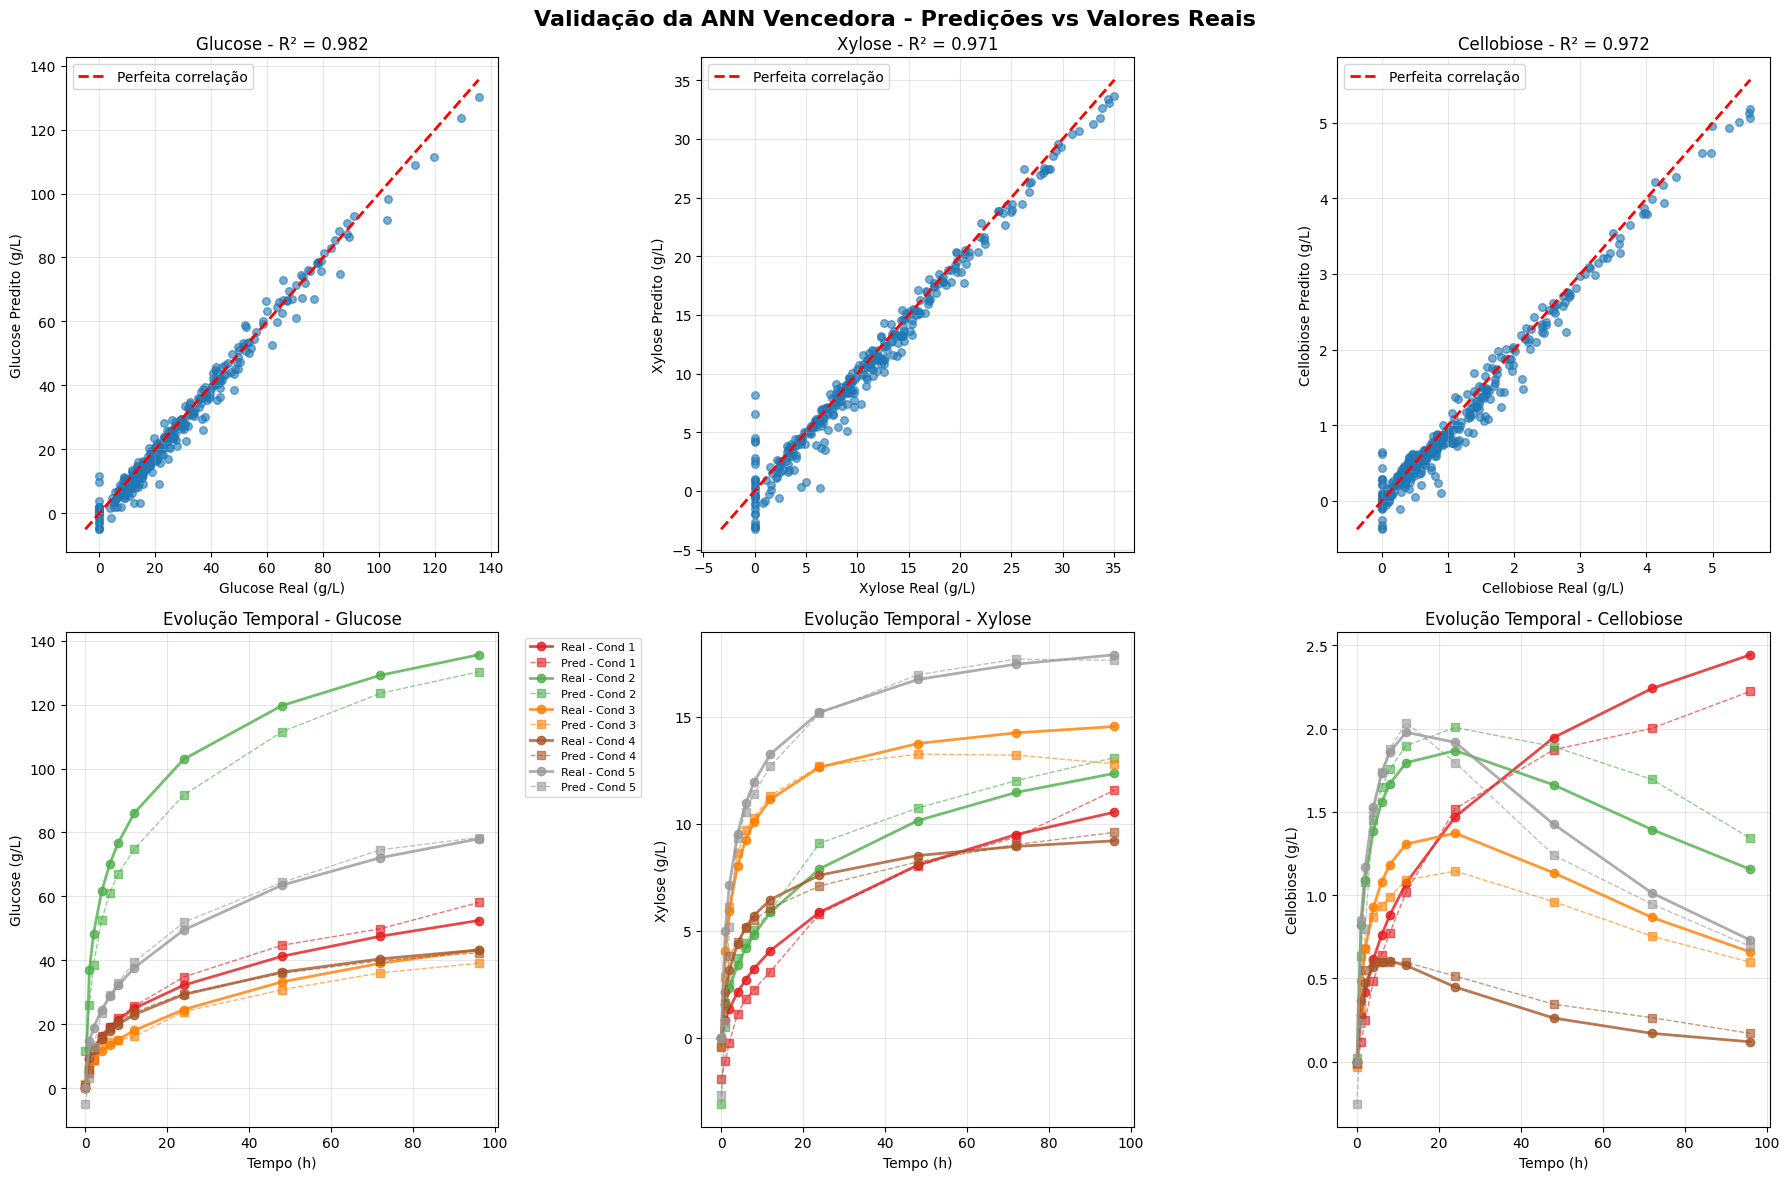


🏆 VALIDAÇÃO FINAL CONCLUÍDA!

📊 RESUMO DA ANN VENCEDORA:
   • Arquitetura: [96, 64, 16] neurônios
   • Parâmetros totais: ~7,971
   • Fitness durante otimização: 0.8698
   • Fitness no teste final: 0.9768

🎯 PERFORMANCE POR PRODUTO (teste final):
   • Glucose: R² = 0.982, RMSE = 3.34 g/L
   • Xylose: R² = 0.971, RMSE = 1.37 g/L
   • Cellobiose: R² = 0.972, RMSE = 0.20 g/L

✅ A ANN vencedora está pronta para uso em predições de hidrólise enzimática!
✅ Modelo otimizado com algoritmo genético e validado em dados nunca vistos!

💾 Modelo salvo como: champion_ann_model_96_64_16.h5


In [22]:
# ============================================================================
# 6. VALIDAÇÃO FINAL DA ANN VENCEDORA
# ============================================================================

print("\n6. VALIDANDO ANN VENCEDORA COM DADOS DE TESTE...")

# Recriar e treinar a melhor ANN encontrada
print(f"🏆 RECRIANDO ANN VENCEDORA...")
print(f"   • Arquitetura: [{best_neurons_l1}, {best_neurons_l2}, {best_neurons_l3}] neurônios")

# Criar modelo vencedor
champion_model = create_model(best_neurons_l1, best_neurons_l2, best_neurons_l3)

# Treinar modelo vencedor com todos os dados de otimização (treino + validação)
print(f"\n🎯 TREINANDO MODELO VENCEDOR...")
print(f"   • Usando TODOS os dados de otimização: {len(optimization_data)} amostras")

# Combinar dados de treino e validação para treino final
X_optimization = optimization_data[input_features].values
y_optimization = optimization_data[output_features].values

# Normalizar dados de otimização
X_opt_scaled = scaler_X.transform(X_optimization)
y_opt_scaled = scaler_y.transform(y_optimization)

# Configurar callbacks
early_stopping = keras.callbacks.EarlyStopping(
    monitor='loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='loss',
    factor=0.5,
    patience=10,
    min_lr=1e-6,
    verbose=1
)

# Treinar modelo final
history = champion_model.fit(
    X_opt_scaled, y_opt_scaled,
    epochs=150,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

print(f"✅ Modelo vencedor treinado com sucesso!")

# Fazer predições no conjunto de teste (30% nunca visto)
print(f"\n🧪 TESTANDO NO CONJUNTO FINAL (30% dos dados)...")
print(f"   • Dados de teste: {len(test_data)} amostras de {len(test_condition_indices)} condições")

# Predições no conjunto de teste
y_test_pred_scaled = champion_model.predict(X_test_scaled, verbose=0)
y_test_pred = scaler_y.inverse_transform(y_test_pred_scaled)

# Calcular métricas detalhadas para cada produto
products = ['Glucose', 'Xylose', 'Cellobiose']
print(f"\n📊 MÉTRICAS DE PERFORMANCE POR PRODUTO:")

metrics_results = {}
for i, product in enumerate(products):
    # Métricas
    r2 = r2_score(y_test[:, i], y_test_pred[:, i])
    rmse = np.sqrt(mean_squared_error(y_test[:, i], y_test_pred[:, i]))
    mae = mean_absolute_error(y_test[:, i], y_test_pred[:, i])
    
    # ⚡ CALCULAR MAPE CORRIGIDO - evitar divisão por valores próximos de zero
    # Só calcular MAPE para valores reais > 1.0 g/L (evitar divisão por valores muito pequenos)
    valid_mask = y_test[:, i] > 1.0  # Apenas valores > 1.0 g/L
    if np.sum(valid_mask) > 0:
        mape = np.mean(np.abs((y_test[valid_mask, i] - y_test_pred[valid_mask, i]) / y_test[valid_mask, i])) * 100
    else:
        mape = 0.0  # Se não há valores válidos, MAPE = 0
    
    metrics_results[product] = {'R2': r2, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape}
    
    print(f"\n   {product.upper()}:")
    print(f"      • R² = {r2:.4f}")
    print(f"      • RMSE = {rmse:.3f} g/L")
    print(f"      • MAE = {mae:.3f} g/L")
    print(f"      • MAPE = {mape:.2f}%")

# Fitness final ponderado
final_fitness = (0.5 * metrics_results['Glucose']['R2'] + 
                0.3 * metrics_results['Xylose']['R2'] + 
                0.2 * metrics_results['Cellobiose']['R2'])

print(f"\n🎯 FITNESS FINAL PONDERADO: {final_fitness:.4f}")

# Criar visualizações das predições
print(f"\n📈 CRIANDO VISUALIZAÇÕES DAS PREDIÇÕES...")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Validação da ANN Vencedora - Predições vs Valores Reais', fontsize=16, fontweight='bold')

# Plot 1-3: Scatter plots para cada produto
for i, product in enumerate(products):
    ax = axes[0, i]
    
    # Scatter plot
    ax.scatter(y_test[:, i], y_test_pred[:, i], alpha=0.6, s=30)
    
    # Linha de perfeita correlação
    min_val = min(y_test[:, i].min(), y_test_pred[:, i].min())
    max_val = max(y_test[:, i].max(), y_test_pred[:, i].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfeita correlação')
    
    # Configurações
    ax.set_xlabel(f'{product} Real (g/L)')
    ax.set_ylabel(f'{product} Predito (g/L)')
    ax.set_title(f'{product} - R² = {metrics_results[product]["R2"]:.3f}')
    ax.grid(True, alpha=0.3)
    ax.legend()

# Plot 4-6: Evolução temporal para algumas condições
for i, product in enumerate(products):
    ax = axes[1, i]
    
    # Selecionar algumas condições para visualizar
    n_conditions_to_show = 5
    selected_test_conditions = test_condition_indices[:n_conditions_to_show]
    
    colors = plt.cm.Set1(np.linspace(0, 1, n_conditions_to_show))
    
    for j, condition_idx in enumerate(selected_test_conditions):
        # Extrair dados desta condição
        condition = unique_conditions.iloc[condition_idx]
        condition_mask = True
        for col in condition_columns:
            condition_mask = condition_mask & (test_data[col] == condition[col])
        
        condition_test_data = test_data[condition_mask].sort_values('Time [h]')
        
        if len(condition_test_data) > 0:
            # Fazer predições para esta condição
            X_condition = condition_test_data[input_features].values
            X_condition_scaled = scaler_X.transform(X_condition)
            y_condition_pred_scaled = champion_model.predict(X_condition_scaled, verbose=0)
            y_condition_pred = scaler_y.inverse_transform(y_condition_pred_scaled)
            
            # Plot
            times = condition_test_data['Time [h]'].values
            real_values = condition_test_data[f'{product} Concentration [g/L]'].values
            pred_values = y_condition_pred[:, i]
            
            ax.plot(times, real_values, 'o-', color=colors[j], alpha=0.8, 
                   label=f'Real - Cond {j+1}', linewidth=2)
            ax.plot(times, pred_values, 's--', color=colors[j], alpha=0.6, 
                   label=f'Pred - Cond {j+1}', linewidth=1)
    
    ax.set_xlabel('Tempo (h)')
    ax.set_ylabel(f'{product} (g/L)')
    ax.set_title(f'Evolução Temporal - {product}')
    ax.grid(True, alpha=0.3)
    if i == 0:  # Mostrar legenda apenas no primeiro subplot
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

# Resumo final
print(f"\n" + "=" * 80)
print(f"🏆 VALIDAÇÃO FINAL CONCLUÍDA!")
print(f"=" * 80)

print(f"\n📊 RESUMO DA ANN VENCEDORA:")
print(f"   • Arquitetura: [{best_neurons_l1}, {best_neurons_l2}, {best_neurons_l3}] neurônios")
print(f"   • Parâmetros totais: ~{champion_model.count_params():,}")
print(f"   • Fitness durante otimização: {best_fitness:.4f}")
print(f"   • Fitness no teste final: {final_fitness:.4f}")

print(f"\n🎯 PERFORMANCE POR PRODUTO (teste final):")
for product in products:
    r2 = metrics_results[product]['R2']
    rmse = metrics_results[product]['RMSE']
    print(f"   • {product}: R² = {r2:.3f}, RMSE = {rmse:.2f} g/L")

print(f"\n✅ A ANN vencedora está pronta para uso em predições de hidrólise enzimática!")
print(f"✅ Modelo otimizado com algoritmo genético e validado em dados nunca vistos!")

# Salvar modelo (opcional)
model_filename = f'champion_ann_model_{best_neurons_l1}_{best_neurons_l2}_{best_neurons_l3}.h5'
champion_model.save(model_filename)
print(f"\n💾 Modelo salvo como: {model_filename}")